/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:88: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 641us/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 755us/step


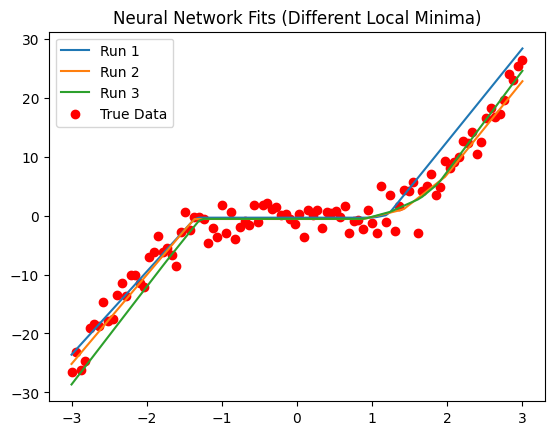

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
import numpy as np 
import matplotlib.pyplot as plt

# Generate non-linear data
X = np.linspace(-3, 3, 100)
y = X ** 3 + np.random.randn(100) * 2

# Define a simple neural network
model = Sequential([
    Dense(10, activation='relu', input_shape=(1,)),
    Dense(1)
])

model.compile(optimizer=SGD(learning_rate=0.01), loss='mse')

# Train multiple times to see different local minima
for run in range(3):
    model.fit(X, y, epochs=100, verbose=0)
    y_pred = model.predict(X)
    plt.plot(X, y_pred, label=f'Run {run+1}')

plt.scatter(X, y, color='red', label='True Data')
plt.legend()
plt.title("Neural Network Fits (Different Local Minima)")
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/stepWARNING:tensorflow:5 out of the last 17 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x161c46660> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


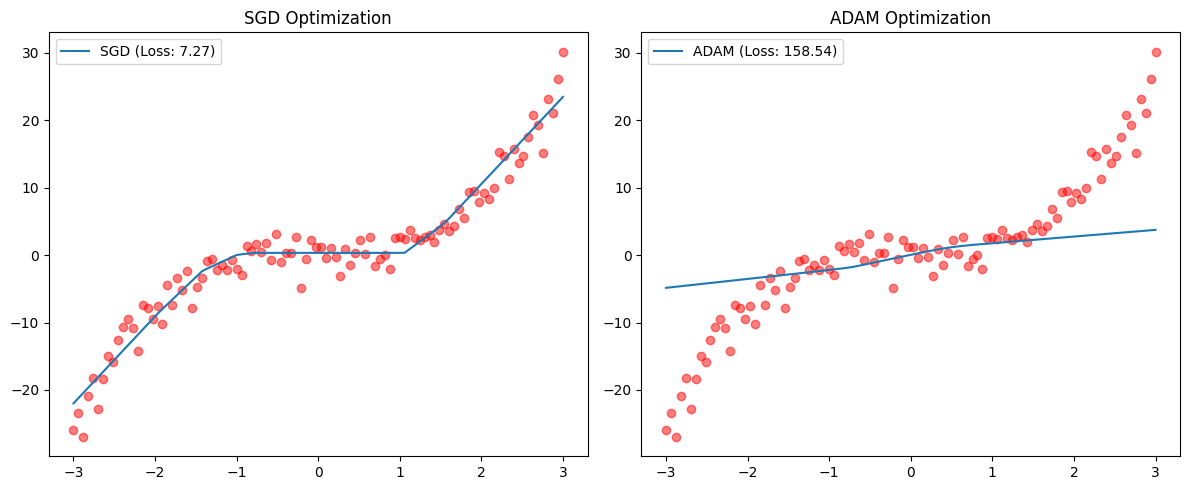

In [3]:
# Generate data
X = np.linspace(-3, 3, 100)
y = X ** 3 + np.random.randn(100) * 2

# Define a simple model
def build_model():
    return Sequential([
        Dense(10, activation='relu', input_shape=(1,)),
        Dense(1)
    ])

# Compare SGD vs Adam
plt.figure(figsize=(12, 5))
for i, optimizer in enumerate(['sgd', 'adam']):
    model = build_model()
    model.compile(optimizer=optimizer, loss='mse')
    model.fit(X, y, epochs=100, verbose=0)
    y_pred = model.predict(X)
    
    plt.subplot(1, 2, i+1)
    plt.scatter(X, y, color='red', alpha=0.5)
    plt.plot(X, y_pred, label=f'{optimizer.upper()} (Loss: {model.evaluate(X, y, verbose=0):.2f})')
    plt.title(f'{optimizer.upper()} Optimization')
    plt.legend()

plt.tight_layout()
plt.show()